# Giới thiệu
Tập hợp Mandelbrot là tập hợp tất cả những số phức $z \in \mathbb{C}$ sao cho dãy $(x_n)_{n \in \mathbb{N}}$ sau đây vẫn bị chặn khi $n → ∞$
$$ \begin{cases}
x_0 = 0 \\
x_n = x_{n-1}^2 + z
\end{cases}
$$
![Tập hợp Mandelbrot](https://upload.wikimedia.org/wikipedia/commons/2/21/Mandel_zoom_00_mandelbrot_set.jpg)

Trong bài tập này, sinh viên sẽ tìm cách tạo một video quá trình phóng to tập hợp Maldelbrot tại một điểm cho trước.

# Yêu cầu bài tập
Sinh viên tạo một video dài 20s, 30 FPS, độ phân giải 1920 x 1080 (Full HD) để biểu diễn việc phóng to $10^6$ (một triệu) lần tập hợp Maldelbrot tại một điểm cho trước.

# Hướng dẫn
Sinh viên được cung cấp hàm `mset(center, width)` như dưới đây để vẽ tập hợp Maldelbrot tại một điểm cho trước. Ý nghĩa các tham số:
- `center`: một tuple 2 thành phần, đại diện tọa độ tâm của hình vẽ.
- `width`: một số, đại diện cho kích thước khu vực vẽ.
Mặc định, hàm sẽ trả về một `ndarray` với kích thước `(1080, 1920)`. Sinh viên có thể biểu diễn `ndarray` này thành hình ảnh bằng `plt.imshow()`. Xem chi tiết ở dưới.


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

from numba import guvectorize, njit, complex128, int32, float64

@njit(float64(complex128, int32))
def calculate_dem(c: complex, max_iter: int):
    '''
    Hàm tính distance estimation tại điểm c
    '''
    bailout = 1e10
    z = c
    dz = complex(0, 0)
    for i in range(max_iter):
        dz = 2 * dz * z + 1
        z = z * z + c
        modz = abs(z)
        if modz > bailout:
            return modz * math.log(modz) / abs(dz) / 2
    return 0
# tối ưu hóa bằng numba
@guvectorize([(complex128[:], int32, float64[:])], '(n),()->(n)', nopython = True, target = 'parallel')
def mandelbrot(img, max_iter, result):
    for r in range(img.shape[0]):
        result[r] = calculate_dem(img[r], max_iter)
#hàm tính toán chính
def mset(center, width, max_iter = 8000, shape = (1080, 1920)):
    h, w = shape
    x = center[0] + np.arange(-w / 2, w / 2) * width
    y = center[1] - np.arange(-h / 2, h / 2) * width
    c = x + y[:, None] * 1j
    image = np.zeros(shape)

    mandelbrot(c, max_iter, image)
    res = np.tanh(image/width)
    res = 1 - (1 - res) ** 4
    return res

In [ ]:
# cách truyền tham số cho hàm mset()
center = (-1.748768589747256568351, 9.3572166111081456160205e-6)
width = 5e-8 / 1920
t = mset(center, width)

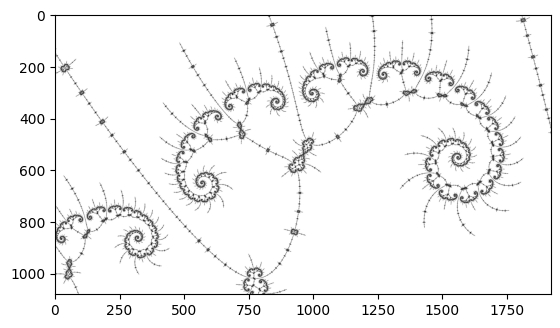

In [ ]:
# biểu diễn kết quả trả về của mset()
plt.imshow(t, cmap = 'grey');

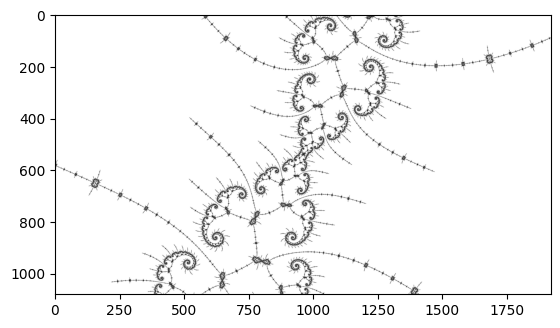

In [ ]:
width = 5e-9 / 1920
t = mset(center, width)
plt.imshow(t, cmap = 'grey');